<img src="https://www.bestdesigns.co/uploads/inspiration_images/4350/990__1511457498_404_walmart.png" alt="WALMART LOGO" width="320" />

# What actually moves Walmart's weekly sales?

Walmart's marketing service wants a model that predicts the weekly sales of a store, and they want
it for a reason: they believe sales follow the economy — fuel price, unemployment, the consumer
price index — and they would like to plan campaigns around those movements.

This notebook builds that model. It reaches **R² = 0.93 on unseen weeks**, which sounds like the
brief is answered. It is not, and the interesting part of the project is why:

> The model is accurate, and **almost none of its accuracy comes from the economy.**
> It comes from knowing *which store* the week belongs to.

Everything below is the evidence for that sentence, in the order the brief asks for it.

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the file and establish what one row is |
| 2 | Clean it — the four rules the brief imposes, and what each one costs |
| 3 | Describe it — where the variance in weekly sales actually lives |
| 4 | Baseline: a linear regression, its score, and its coefficients |
| 5 | Regularisation: Ridge and Lasso, tuned by cross-validation |
| 6 | What the marketing service should take away |

Every cleaning decision is followed by its measured effect, and every claim below is the output of
the cell above it.

## 1. Loading the data

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One warning is silenced, and only one. With 19 stores over 90 training rows, a cross-validation
# fold can contain a store the fold's training half never saw; the encoder is configured with
# handle_unknown='ignore' precisely so that this is handled rather than fatal (see section 4.1), and
# it says so once per occurrence. Section 5 fits 160 models, so the notice would bury its own output.
warnings.filterwarnings('ignore', message='Found unknown categories',
                        category=UserWarning, module='sklearn')

# One seed for the whole notebook: the train/test split, the cross-validation folds and the
# stability study in section 5 all read it, so every number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a sign.
BLUE, RED, GREY = '#2a78d6', '#e34948', '#8a8a85'


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()


def money(x):
    """1249536.4 -> '1 249 536'. Used in labels, where dollars beat scientific notation."""
    return f'{x:,.0f}'.replace(',', ' ')

In [2]:
df_source = pd.read_csv('Walmart_Store_sales.csv')

print(f'{df_source.shape[0]} rows x {df_source.shape[1]} columns')
df_source.head()

150 rows x 8 columns


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


### What is one row?

**One row is one store in one week.** `Weekly_Sales` is the total takings of that store over that
week, and the five other columns describe the conditions around it: whether the week contained a
public holiday, and four indicators — temperature, fuel price, consumer price index, unemployment
rate — measured for the region the store sits in.

Two properties of the file matter more than anything else that follows, and the cell below
establishes both.

In [3]:
# --- The scale of the file ------------------------------------------------------------------
dates = pd.to_datetime(df_source['Date'], format='%d-%m-%Y', errors='coerce')
print(f'stores          : {df_source["Store"].nunique()}')
print(f'weeks covered   : {dates.min():%d %b %Y} to {dates.max():%d %b %Y}')
print(f'rows per store  : {df_source["Store"].value_counts().min()} to '
      f'{df_source["Store"].value_counts().max()}')
print(f'duplicated rows : {df_source.duplicated().sum()}')

# --- Where the holes are --------------------------------------------------------------------
# Not an aside: half of this file is incomplete, and that fact drives every choice in section 2.
missing = df_source.isna().sum()
print(f'\nrows that are complete : {df_source.notna().all(axis=1).sum()} / {len(df_source)}')

stores          : 20
weeks covered   : 05 Feb 2010 to 19 Oct 2012
rows per store  : 3 to 15
duplicated rows : 0

rows that are complete : 75 / 150


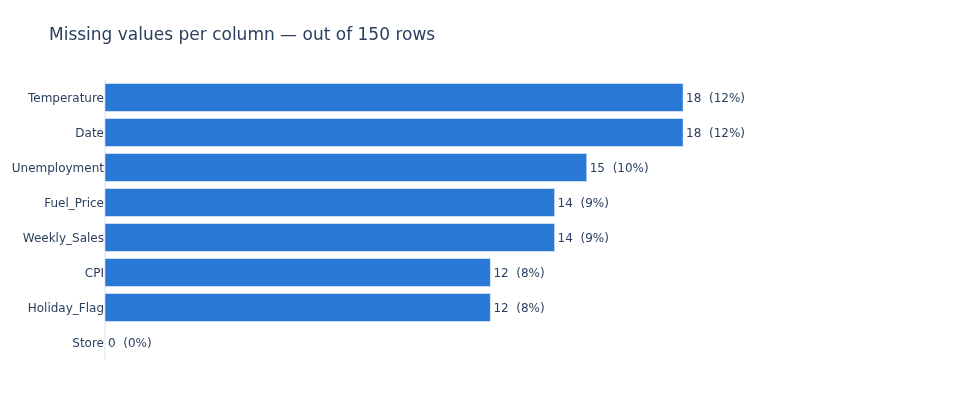

In [4]:
m = missing.sort_values()
fig = go.Figure(go.Bar(
    x=m.values, y=m.index, orientation='h', marker_color=BLUE,
    text=[f'{v}  ({v / len(df_source):.0%})' for v in m.values],
    textposition='outside', cliponaxis=False,
))
fig.update_layout(
    title='Missing values per column — out of 150 rows',
    xaxis=dict(title=None, showgrid=False, showticklabels=False, range=[0, 26]),
    yaxis=dict(title=None),
)
show(fig, '1_missing_values', height=420)

The holes are **spread evenly across seven of the eight columns**, 8% to 12% each — `Store` is the
only one with nothing missing — and they do not fall on the same rows.

That rules out the easy answer. `dropna()` on the whole table would keep **75 rows out of 150** —
half the dataset thrown away to fix a tenth of the values. So the missing values get handled per
column, by what the column *is*, which is section 2.

## 2. Cleaning

The brief imposes four rules. Each one is applied below and **followed by what it cost**, because
on a file this small every rule is expensive and two of them cost more than they look.

### 2.1 Drop the rows with no target

The target is `Weekly_Sales`. Fourteen rows do not have one.

These rows cannot be repaired: imputing a target means inventing the answer the model is graded on,
and every score afterwards would be partly a measure of how well the model reproduces our own
filling rule. The rows go.

In [5]:
df = df_source.dropna(subset=['Weekly_Sales']).copy()
print(f'{len(df_source)} rows -> {len(df)} rows  ({len(df_source) - len(df)} dropped: no target)')

150 rows -> 136 rows  (14 dropped: no target)


### 2.2 Turn `Date` into numbers — and drop the rows that have no date

`Date` is a string, and a model cannot read `'18-02-2011'`. The brief asks for four numeric
features out of it: *year*, *month*, *day* and *day of week*.

Eighteen of the remaining rows have no date at all. There is no honest way to fill them: a median
year or a median month is not a plausible date for anything, it is the middle of the file's
calendar dropped into a row that never had one. They go too — 13% of an already small dataset, and
that is the price of not making things up.

In [6]:
before = len(df)
df = df.dropna(subset=['Date'])
dates = pd.to_datetime(df['Date'], format='%d-%m-%Y')   # no errors='coerce': every remaining
                                                        # date must parse, and all 118 do
df = df.assign(Year=dates.dt.year, Month=dates.dt.month,
               Day=dates.dt.day, DayOfWeek=dates.dt.dayofweek).drop(columns=['Date'])

print(f'{before} rows -> {len(df)} rows  ({before - len(df)} dropped: no date)\n')
for col in ['Year', 'Month', 'Day', 'DayOfWeek']:
    values = sorted(int(v) for v in df[col].unique())
    print(f'{col:10s} {len(values):2d} distinct value(s): {values[:6]}'
          f'{" ..." if len(values) > 6 else ""}')

136 rows -> 118 rows  (18 dropped: no date)

Year        3 distinct value(s): [2010, 2011, 2012]
Month      12 distinct value(s): [1, 2, 3, 4, 5, 6] ...
Day        30 distinct value(s): [1, 2, 3, 4, 5, 6] ...
DayOfWeek   1 distinct value(s): [4]


**`DayOfWeek` is constant.** Every week in this file is dated on a Friday, so the fourth feature
the brief asks for has zero variance and can carry no information at all — a column of identical
values cannot explain a target that varies.

It is kept anyway, deliberately: the brief asks for it, and it is more useful as a live
demonstration than as a deleted line. `StandardScaler` will divide it by a standard deviation of
zero and return a column of zeros, its regression coefficient will be exactly `0`, and Lasso will
be the first model to say so out loud in section 5.

### 2.3 Drop the outliers — and notice what leaves with them

The rule is imposed: on `Temperature`, `Fuel_Price`, `CPI` and `Unemployment`, anything outside
$[\bar{X} - 3\sigma,\ \bar{X} + 3\sigma]$ is an outlier and its row goes.

In [7]:
OUTLIER_COLS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

keep = pd.Series(True, index=df.index)
for col in OUTLIER_COLS:
    mean, std = df[col].mean(), df[col].std()
    # .fillna(False): a missing value is not an outlier. Without it NaN >= bound is False anyway,
    # but the intent is worth writing down -- these rows are handled by imputation, not by exclusion.
    outside = ((df[col] < mean - 3 * std) | (df[col] > mean + 3 * std)).fillna(False)
    print(f'{col:14s} keep [{mean - 3 * std:8.2f}, {mean + 3 * std:8.2f}]   '
          f'{outside.sum()} outlier(s)')
    keep &= ~outside

print(f'\n{len(df)} rows -> {keep.sum()} rows  ({(~keep).sum()} dropped: outliers)')
df[~keep][['Store', 'Weekly_Sales', 'Unemployment', 'CPI']]

Temperature    keep [    6.83,   114.60]   0 outlier(s)
Fuel_Price     keep [    1.83,     4.75]   0 outlier(s)
CPI            keep [   58.27,   297.17]   0 outlier(s)
Unemployment   keep [    2.65,    12.72]   5 outlier(s)

118 rows -> 113 rows  (5 dropped: outliers)


,Store,Weekly_Sales,Unemployment,CPI
30,12.0,1021154.48,13.736,129.044433
62,12.0,1295605.35,14.313,126.879484
68,12.0,955913.68,13.503,129.201581
93,12.0,964332.51,13.736,129.062355
135,12.0,903119.03,14.180,126.114581


Three of the four columns have no outlier at all. The five rows that leave are all
`Unemployment` above 12.7% — and they are **all store 12, which is every row store 12 has.**

So the rule does not remove five unusual weeks. It removes **one store**, a location in a county
with 13-14% unemployment, and it removes it precisely *because* its region is unusual. The dataset
goes from 20 stores to 19, and the model will never be able to predict for store 12.

That is worth saying plainly rather than hiding: a ±3σ filter treats a stable regional
characteristic as if it were a measurement error. On this dataset it is the brief's rule and it is
applied as asked — but if this model were going into production, this is the line to revisit first.

In [8]:
df = df[keep]
print(f'analysis dataset: {df.shape[0]} rows x {df.shape[1]} columns, {df["Store"].nunique()} stores')

analysis dataset: 113 rows x 11 columns, 19 stores


### 2.4 What is still missing, and why pandas does not touch it

In [9]:
still_missing = df.isna().sum()
print(still_missing[still_missing > 0].to_string())

Holiday_Flag     9
Temperature     10
Fuel_Price      11
CPI              9
Unemployment    11


Forty holes are left, in the four indicators and the holiday flag. They are **not** filled here.

Filling them now would compute a median over the whole dataset, test rows included, and hand the
model a value that already knows something about the weeks it will be graded on. Imputation belongs
inside the scikit-learn pipeline, fitted on the training set only — which is section 4.

One caveat in the same spirit, and it is a real one: the ±3σ bounds above *were* computed over the
whole dataset, before the split. The brief specifies it as a pandas step, so that is where it sits,
but it is a small leak and it should be named rather than glossed over.

## 3. Where the variance in weekly sales lives

Before any model, one question decides how to read everything after it: **what makes one week's
sales different from another's?**

In [10]:
print(df['Weekly_Sales'].describe().apply(money).to_string())

count          113
mean     1 267 415
std        674 682
min        268 929
25%        563 461
50%      1 420 405
75%      1 847 431
max      2 771 397


Weekly sales run from **269 k$ to 2.77 M$** — a factor of ten between the smallest week and the
largest — around a mean of 1.27 M$. Any model has to explain a spread of roughly ±675 k$, and that
number is the yardstick for every RMSE below.

### 3.1 The store explains most of it

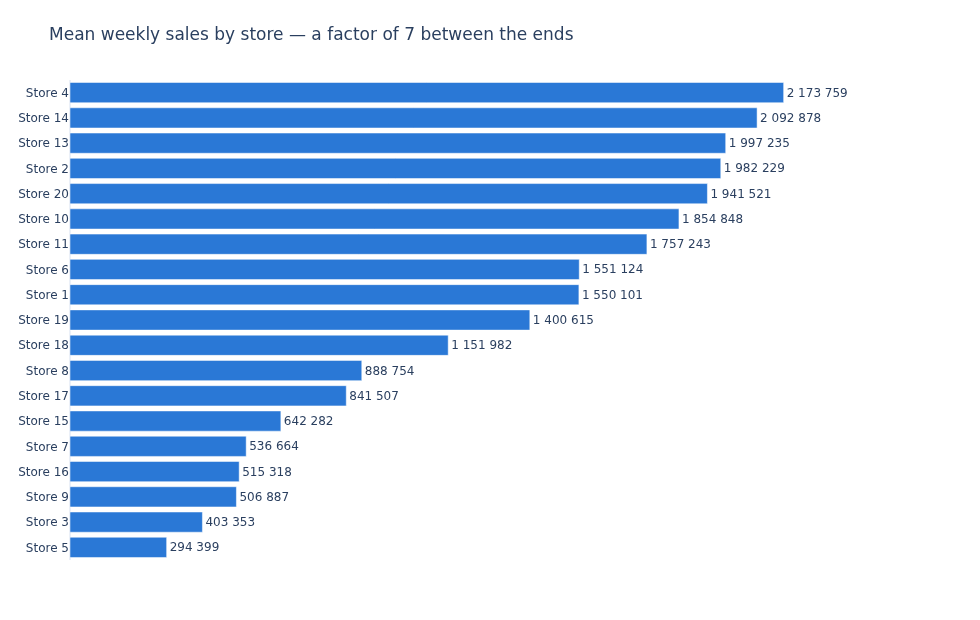

store 4 sells 7.4x what store 5 sells


In [11]:
by_store = df.groupby('Store')['Weekly_Sales'].mean().sort_values()

fig = go.Figure(go.Bar(
    x=by_store.values, y=[f'Store {int(s)}' for s in by_store.index], orientation='h',
    marker_color=BLUE, text=[money(v) for v in by_store.values],
    textposition='outside', cliponaxis=False,
))
fig.update_layout(
    title='Mean weekly sales by store — a factor of 7 between the ends',
    xaxis=dict(title=None, showgrid=False, showticklabels=False, range=[0, 2_650_000]),
    yaxis=dict(title=None),
)
show(fig, '2_sales_by_store', height=620)

print(f'store {int(by_store.index[-1])} sells {by_store.iloc[-1] / by_store.iloc[0]:.1f}x '
      f'what store {int(by_store.index[0])} sells')

The stores are not variations on a theme, they are different businesses: store 4 takes **2.17 M$**
in an average week, store 5 takes **294 k$**. That gap is as wide as the whole spread of the target,
which means a model that knows nothing but the store number already has most of the answer.

### 3.2 The economic indicators explain very little

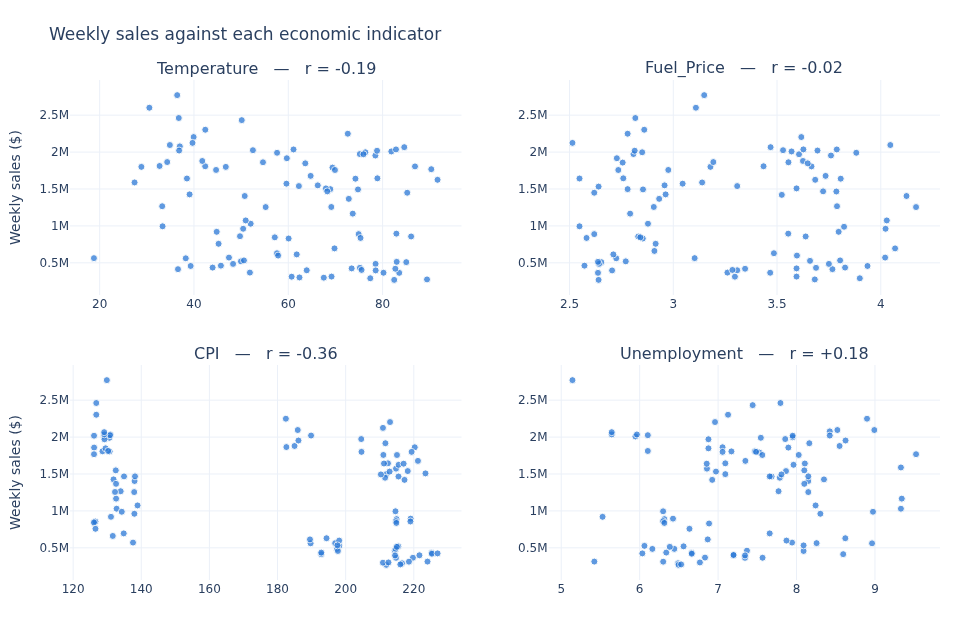

Temperature    -0.193
Fuel_Price     -0.022
CPI            -0.361
Unemployment    0.175
Year           -0.040
Month          -0.013
Day            -0.036
DayOfWeek         NaN


In [12]:
NUMERIC = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']
INDICATORS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

corr = df[['Weekly_Sales'] + NUMERIC].corr()['Weekly_Sales'].drop('Weekly_Sales')

fig = make_subplots(rows=2, cols=2, subplot_titles=[
    f'{c}   —   r = {corr[c]:+.2f}' for c in INDICATORS], vertical_spacing=0.14)
for i, col in enumerate(INDICATORS):
    fig.add_trace(go.Scatter(
        x=df[col], y=df['Weekly_Sales'], mode='markers',
        marker=dict(color=BLUE, size=7, opacity=0.75,
                    line=dict(width=1, color='#fcfcfb')),   # 2px surface ring, so points that
        showlegend=False), row=i // 2 + 1, col=i % 2 + 1)   # overlap stay countable
fig.update_yaxes(title_text='Weekly sales ($)', col=1)
fig.update_layout(title='Weekly sales against each economic indicator')
show(fig, '3_indicators_vs_sales', height=640)

print(corr.round(3).to_string())

No panel shows a slope. The correlations agree: `Fuel_Price` **−0.02**, `Unemployment` **+0.18**,
`Temperature` **−0.19**. `DayOfWeek` returns `NaN`, which is the constant column of section 2.2
confirming itself — a correlation needs two variables that vary.

`CPI` carries the strongest number in the table at **−0.36**, and its panel is also the one that
does not look like the others: the points sit in **three separate vertical clusters** with empty
space between them, around 126-140, 180-200 and 205-227. A variable that moves continuously with
the economy does not do that. The next cell measures what those clusters are.

In [13]:
# Is each indicator a property of the WEEK, or a property of the STORE wearing a week's name?
# Split each column's variance: how much of it separates stores, and how much of it moves inside
# a store over time. An indicator that is entirely between-store carries no weekly information.
print(f'{"indicator":14s} {"variance between stores":>24s}')
for col in INDICATORS:
    d = df[['Store', col]].dropna()
    store_mean = d.groupby('Store')[col].transform('mean')
    between = ((store_mean - d[col].mean()) ** 2).sum()
    total = ((d[col] - d[col].mean()) ** 2).sum()
    print(f'{col:14s} {between / total:>23.1%}')

spread = df.groupby('Store')['CPI'].agg(lambda s: s.max() - s.min())
print(f'\nCPI moves by {spread.median():.1f} points inside a store, against a range of '
      f'{df["CPI"].max() - df["CPI"].min():.1f} points across the file')

indicator       variance between stores
Temperature                      34.5%
Fuel_Price                       23.3%
CPI                              99.4%
Unemployment                     75.5%

CPI moves by 6.3 points inside a store, against a range of 100.9 points across the file


**`CPI` is not an economic variable in this dataset — it is a store label.** 99.4% of its variance
separates stores rather than weeks: each store sits in its own region, each region has its own
price index, and over the two and a half years covered here that index barely moves (6.3 points
inside a store, against a 101-point range across the file).

So the −0.36 correlation is the store effect of section 3.1 wearing an economic name. `CPI` will
look important in the model, and it will be telling us *where the store is*, not what the economy
did.

`Unemployment` has the same problem at 75%. Only `Temperature` (35%) and `Fuel_Price` (23%) are
genuinely week-to-week quantities.

### 3.3 The holiday flag is too rare to read

In [14]:
print(df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['count', 'mean']).round(0).to_string())

              count       mean
Holiday_Flag                  
0.0              97  1258426.0
1.0               7  1347476.0


**Seven holiday weeks** out of 113. They average 89 k$ more than the others, which on a target
whose standard deviation is 675 k$ and a sample of seven is indistinguishable from nothing. The
feature stays in the model because the brief asks for it, but no reading of its coefficient would
survive a second dataset.

## 4. Baseline — linear regression

### 4.1 The preprocessing pipeline

Two families of columns, treated differently, and both fitted **on the training set only** so that
nothing about the test weeks leaks into the model:

- **Numerical** — median imputation, then standardisation. The median rather than the mean because
  it is not dragged by the tails; standardisation because the columns share no unit (a fuel price
  in dollars, an unemployment rate in percent, a month between 1 and 12) and their coefficients are
  only comparable once they do.
- **Categorical** — `Store` and `Holiday_Flag`, most-frequent imputation, then one-hot encoding.
  `Store` is numeric in the file, but store 20 is not "twice store 10": these are labels, and
  leaving them as numbers would ask the model to fit a straight line through an arbitrary ordering.

In [15]:
CATEGORICAL = ['Store', 'Holiday_Flag']

y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), NUMERIC),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      # drop='first': with an intercept in the model, keeping all 19 store columns
                      # would make them perfectly collinear with it and the coefficients arbitrary.
                      # One store becomes the reference and the others are read against it.
                      # handle_unknown='ignore': 90 training rows over 19 stores, so a store can
                      # miss the training set entirely -- encode it as all-zeros rather than crash.
                      ('encode', OneHotEncoder(drop='first', handle_unknown='ignore',
                                               sparse_output=False))]), CATEGORICAL),
])

print(f'train {X_train.shape[0]} rows   test {X_test.shape[0]} rows')
print(f'features after encoding: {preprocessor.fit(X_train).transform(X_train).shape[1]}')
print(f'stores present in the training set: {X_train["Store"].nunique()} / {X["Store"].nunique()}')

train 90 rows   test 23 rows
features after encoding: 27
stores present in the training set: 19 / 19


**27 features for 90 training rows.** That ratio is the reason part 3 of the brief exists, and it
is the first thing the scores below have to be read against.

### 4.2 Fit and score

`R²` is the headline metric — it is unitless, so train and test are directly comparable — reported
next to `RMSE`, which is in dollars and is what a marketing team can actually act on.

In [16]:
def score(model, name):
    """Fit on train, score on both sides, and return one row of the comparison table."""
    model.fit(X_train, y_train)
    train_pred, test_pred = model.predict(X_train), model.predict(X_test)
    return {
        'model': name,
        'R2 train': r2_score(y_train, train_pred),
        'R2 test': r2_score(y_test, test_pred),
        'RMSE train': root_mean_squared_error(y_train, train_pred),
        'RMSE test': root_mean_squared_error(y_test, test_pred),
    }


baseline = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
results = [score(baseline, 'LinearRegression')]

# The reference every score is read against: predicting the training mean for every week.
naive = root_mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))

print(pd.DataFrame(results).round(3).to_string(index=False))
print(f'\nfor reference, predicting the mean every week: RMSE test {money(naive)} $')

           model  R2 train  R2 test  RMSE train  RMSE test
LinearRegression     0.975    0.932  108522.221 152052.004

for reference, predicting the mean every week: RMSE test 584 765 $


**R² = 0.975 on train, 0.932 on test.** The model is genuinely good: it misses an average week by
about **152 k$** where predicting the mean misses by **585 k$**, a four-fold improvement on a
target that spans 269 k$ to 2.77 M$.

The 4-point drop from train to test is the 27-features-for-90-rows ratio showing up, and it is
small — smaller than it has any right to be. Section 5 is where that gets tested properly.

### 4.3 What the coefficients say

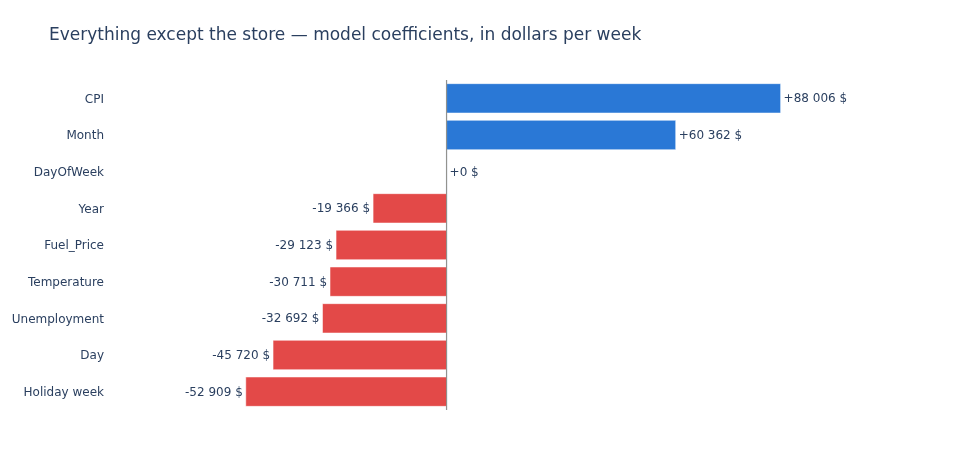

store coefficients run from -1 280 409 to +677 699 $, against a widest non-store coefficient of 88 006 $
DayOfWeek coefficient: 0.0


In [17]:
feature_names = baseline.named_steps['pre'].get_feature_names_out()
coefs = pd.Series(baseline.named_steps['model'].coef_, index=feature_names)

store_coefs = coefs[[n for n in feature_names if 'Store' in n]]
other = coefs.drop(store_coefs.index).sort_values()
other.index = [n.split('__')[1].replace('Holiday_Flag_1.0', 'Holiday week') for n in other.index]

fig = go.Figure(go.Bar(
    x=other.values, y=other.index, orientation='h',
    marker_color=[RED if v < 0 else BLUE for v in other.values],
    text=[f'{v:+,.0f} $'.replace(',', ' ') for v in other.values],
    textposition='outside', cliponaxis=False,
))
fig.add_vline(x=0, line_width=1, line_color=GREY)
fig.update_layout(
    title='Everything except the store — model coefficients, in dollars per week',
    xaxis=dict(title=None, showgrid=False, showticklabels=False, range=[-90_000, 130_000]),
    yaxis=dict(title=None),
)
show(fig, '4_coefficients', height=470)

print(f'store coefficients run from {money(store_coefs.min())} to +{money(store_coefs.max())} $, '
      f'against a widest non-store coefficient of {money(abs(other).max())} $')
print(f'DayOfWeek coefficient: {coefs["num__DayOfWeek"]:.1f}')

Each numerical column was standardised, so its coefficient reads as *"what a one-standard-deviation
move in this column is worth"*; `Holiday week` is a 0/1 dummy, so its coefficient is the whole
difference between a holiday week and an ordinary one. Either way the two groups are nowhere near
the same scale:

- **The store dummies run from −1.28 M$ to +0.68 M$.** Being store 5 rather than the reference
  store is worth more than a million dollars a week.
- **Everything else fits between −53 k$ and +88 k$** — a fifteenth of that, and roughly the width
  of the model's own error bar.
- **`DayOfWeek` is exactly 0.0**, as section 2.2 said it would be.

The largest of them is `CPI`, which section 3.2 already disarmed: it is a regional label, so the model is using it to refine *which store this is* — and its sign is
positive here while its raw correlation with sales was negative, which is what happens to a
coefficient that is standing in for something else.

This is a claim about what the model is doing, so the next cell tests it directly rather than
leaving it as a reading of the coefficients.

In [18]:
# Rebuild the model on one group of columns at a time and cross-validate each. Cross-validation
# rather than the single split: the point is to rank the groups, and a 23-row test set cannot.
def cv_r2(categorical, numeric):
    pre = ColumnTransformer(
        ([('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                            ('scale', StandardScaler())]), numeric)] if numeric else []) +
        ([('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore',
                                                     sparse_output=False))]), categorical)]
         if categorical else []))
    pipe = Pipeline([('pre', pre), ('model', LinearRegression())])
    folds = KFold(5, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(pipe, X, y, cv=folds, scoring='r2').mean()


groups = {
    'everything (the model above)':        (CATEGORICAL, NUMERIC),
    'Store alone':                         (['Store'], []),
    'the 4 economic indicators alone':     ([], INDICATORS),
    'the 4 date features alone':           ([], ['Year', 'Month', 'Day', 'DayOfWeek']),
    'Holiday_Flag alone':                  (['Holiday_Flag'], []),
    'everything EXCEPT Store':             (['Holiday_Flag'], NUMERIC),
}
for label, (cat, num) in groups.items():
    print(f'{label:32s} CV R2 = {cv_r2(cat, num):+.3f}')

everything (the model above)     CV R2 = +0.934
Store alone                      CV R2 = +0.929
the 4 economic indicators alone  CV R2 = +0.034
the 4 date features alone        CV R2 = -0.144
Holiday_Flag alone               CV R2 = -0.133


everything EXCEPT Store          CV R2 = -0.150


This is the finding of the project.

**The store number alone reaches R² = 0.929.** Adding the economic indicators, the calendar and the
holiday flag on top of it buys **half a point**.

And the last line settles it: a model given *every column the marketing service cares about* and
denied only the store number scores **−0.150** — worse than predicting the same average for every
week of every store. The indicators are not weak predictors here. They are not predictors.

## 5. Regularisation — Ridge and Lasso

Part 3 of the brief asks for a regularised model to fight overfitting. 27 features on 90 rows says
there should be some to fight; the 4-point train/test gap in section 4.2 says there is not much.
The two models below settle it, each with its penalty strength `alpha` tuned by `GridSearchCV`
over 5 folds of the training set.

In [19]:
ALPHAS_RIDGE = np.logspace(-3, 4, 60)     # 0.001 -> 10 000
ALPHAS_LASSO = np.logspace(0, 6, 60)      # 1 -> 1 000 000, higher because Lasso's penalty is
                                          # applied to coefficients measured in dollars

def tuned(model, alphas, name):
    """GridSearchCV over alpha, then score the winner exactly like the baseline."""
    grid = GridSearchCV(Pipeline([('pre', preprocessor), ('model', model)]),
                        {'model__alpha': alphas}, cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    row = score(grid.best_estimator_, name)
    row['alpha'] = grid.best_params_['model__alpha']
    return grid.best_estimator_, row


ridge_model, ridge_row = tuned(Ridge(), ALPHAS_RIDGE, 'Ridge')
lasso_model, lasso_row = tuned(Lasso(max_iter=100_000), ALPHAS_LASSO, 'Lasso')

comparison = pd.DataFrame(results + [ridge_row, lasso_row])
print(comparison.round(3).to_string(index=False))

           model  R2 train  R2 test  RMSE train  RMSE test    alpha
LinearRegression     0.975    0.932  108522.221 152052.004      NaN
           Ridge     0.974    0.920  111429.351 164758.930    0.104
           Lasso     0.972    0.909  114960.366 175940.603 1420.831


The three models are the same model.

Ridge picks **alpha = 0.10** out of a grid that runs to 10 000 — cross-validation was offered seven
orders of magnitude of regularisation and asked for essentially none. Both regularised models land
within a few points of the baseline on test, slightly below it.

That reads like a negative result, and on a single 23-row test set it would be unreadable either
way: the next cell repeats the whole comparison over 40 different splits, because the honest
question is not *"which model won this split"* but *"is the difference between them bigger than the
noise in the split"*.

In [20]:
# 40 splits, each one re-tuning alpha from scratch -- reusing the alpha chosen above would be
# scoring a hyperparameter that had already seen these test rows. Runs in about a minute.
rows, ridge_alphas, coef_runs = [], [], {'LinearRegression': [], 'Ridge': []}

for seed in range(40):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    for name, model, alphas in [('LinearRegression', LinearRegression(), None),
                                ('Ridge', Ridge(), ALPHAS_RIDGE[::3]),
                                ('Lasso', Lasso(max_iter=100_000), ALPHAS_LASSO[::3])]:
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        if alphas is not None:
            grid = GridSearchCV(pipe, {'model__alpha': alphas}, cv=5, scoring='r2').fit(Xtr, ytr)
            pipe = grid.best_estimator_
            if name == 'Ridge':
                ridge_alphas.append(grid.best_params_['model__alpha'])
        else:
            pipe.fit(Xtr, ytr)
        rows.append({'seed': seed, 'model': name, 'R2 test': r2_score(yte, pipe.predict(Xte))})
        # Coefficients too, indexed by name: a split can lose a store and produce one column fewer.
        if name in coef_runs:
            coef_runs[name].append(pd.Series(pipe.named_steps['model'].coef_,
                                             index=pipe.named_steps['pre'].get_feature_names_out()))

splits = pd.DataFrame(rows)
print(splits.groupby('model')['R2 test'].agg(['mean', 'std', 'min', 'max']).round(3).to_string())
print(f'\nRidge alpha chosen by cross-validation over the 40 splits: '
      f'median {np.median(ridge_alphas):.3f}, max {max(ridge_alphas):.2f}')

                   mean    std    min    max
model                                       
Lasso             0.937  0.031  0.815  0.983
LinearRegression  0.939  0.028  0.829  0.978
Ridge             0.938  0.028  0.829  0.981

Ridge alpha chosen by cross-validation over the 40 splits: median 0.027, max 0.31


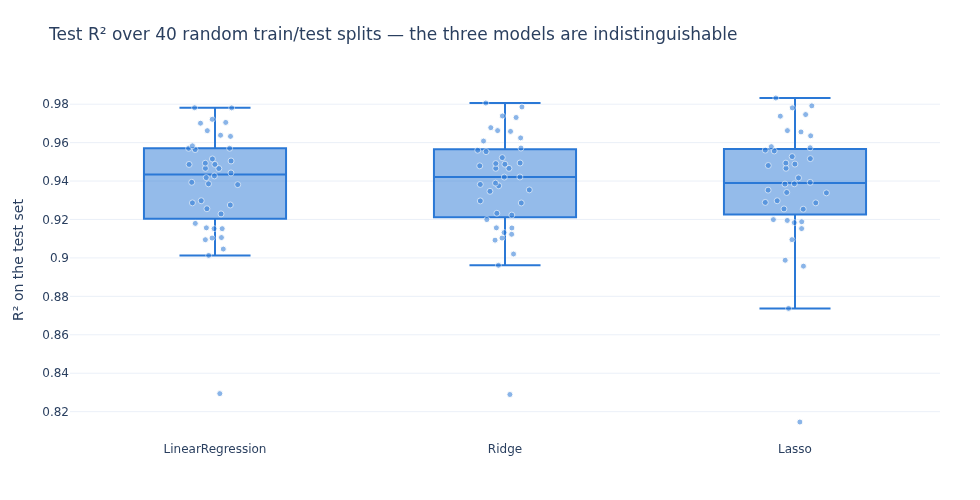

In [21]:
order = ['LinearRegression', 'Ridge', 'Lasso']
fig = go.Figure()
for name in order:
    fig.add_trace(go.Box(
        y=splits.loc[splits['model'] == name, 'R2 test'], name=name,
        marker_color=BLUE, line_width=2, boxpoints='all', jitter=0.5, pointpos=0,
        marker=dict(size=6, opacity=0.55, line=dict(width=1, color='#fcfcfb')),
        showlegend=False,
    ))
fig.update_layout(
    title='Test R² over 40 random train/test splits — the three models are indistinguishable',
    yaxis=dict(title='R² on the test set'), xaxis=dict(title=None),
)
show(fig, '5_model_comparison', height=500)

Averaged over 40 splits, the three models score **0.939, 0.938 and 0.937**. Each one's own spread
runs from 0.82 to 0.98, a standard deviation of 0.03 — more than ten times the 0.002 that separates
their means. Every split's ranking is noise, including the one in the table above.

So the answer to part 3 of the brief is not "regularisation fixed the overfitting". It is:

> **There was no overfitting to fix, and the regularised models found that out by themselves** —
> cross-validation picked a Ridge alpha of 0.03 (median over 40 splits, never above 0.31) out of a
> grid reaching 10 000, which is the model saying it wants no penalty.

The reason is section 4.3: 19 of the 27 features are store dummies, and a store dummy is not a
noisy proxy that a small sample might fit by accident — it is close to a direct measurement of the
answer. There is little spurious structure available to memorise.

In [22]:
# One consequence, because section 4.3 read the coefficients and this is what that reading is worth.
lin_coefs = pd.DataFrame(coef_runs['LinearRegression'])
ridge_coefs = pd.DataFrame(coef_runs['Ridge'])
print(f'median coefficient std-dev over the 40 splits: '
      f'LinearRegression {money(lin_coefs.std().median())} $, Ridge {money(ridge_coefs.std().median())} $')
print(f'coefficients that change sign at least once:   '
      f'LinearRegression {((lin_coefs > 0).any() & (lin_coefs < 0).any()).sum()} / {lin_coefs.shape[1]}, '
      f'Ridge {((ridge_coefs > 0).any() & (ridge_coefs < 0).any()).sum()} / {ridge_coefs.shape[1]}')

nonzero = lasso_model.named_steps['model'].coef_ != 0
print(f'\nLasso at its selected alpha ({lasso_row["alpha"]:.0f}) keeps {nonzero.sum()} of '
      f'{len(nonzero)} features and zeroes: '
      f'{", ".join(n.split("__")[1] for n, k in zip(feature_names, nonzero) if not k)}')

median coefficient std-dev over the 40 splits: LinearRegression 59 893 $, Ridge 63 484 $
coefficients that change sign at least once:   LinearRegression 8 / 27, Ridge 6 / 27

Lasso at its selected alpha (1421) keeps 24 of 27 features and zeroes: DayOfWeek, Store_19.0, Holiday_Flag_1.0


Two closing measurements, both cautions rather than results:

- **Ridge's coefficients are no steadier than the baseline's** (median standard deviation over the
  40 splits: 60 k$ against 63 k$). At an alpha of 0.03 there is nothing to shrink, so the usual
  second benefit of regularisation is not available here either.
- **Eight of the 27 coefficients change sign** depending on which rows land in the training set —
  six for Ridge. They are the small ones: the store dummies of section 4.3 hold their sign, and it
  is the indicator coefficients that flip. One more reason not to read a campaign plan out of them.

Lasso, given a real penalty to spend, spends it exactly where section 4.3 predicted. Of the three
features it drops, two are the ones this notebook has already called empty — `DayOfWeek`, the
constant column, and the holiday flag with its seven weeks. The third is store 19, one of the two
store dummies sitting nearest zero in the baseline (63 k$, against a store range of −1.28 M$ to
+0.68 M$). The seventeen other store dummies are left untouched.

## 6. What the marketing service should take away

**1. The model works, and it can be used.** R² 0.93 on unseen weeks, an average error of 152 k$
against 585 k$ for predicting the mean. For sizing what a given store should take in a given week,
it is fit for purpose.

**2. It works because it knows the store, not because it knows the economy.** The store number
alone scores 0.929; everything else together adds half a point. A model given every economic
indicator, the calendar and the holiday flag, but not the store number, scores **−0.150** — worse
than a flat average.

**3. The one indicator that looks predictive is not one.** `CPI` carries the strongest correlation
with sales (−0.36) and the largest non-store coefficient, but 99.4% of its variance separates
stores rather than weeks. It is a regional label, and the model uses it as one.

**4. So the question the brief asks cannot be answered from this file — and that is a property of
the file, not a failure of the model.** 113 usable weeks, spread over 19 stores, is roughly six
observations per store across two and a half years. Fuel price and unemployment move slowly; six
points per store is not enough to see a slow effect through a ±675 k$ spread. The full Kaggle
dataset this extract comes from has 45 stores × 143 weeks — 6 400 rows against our 113 — and it is
where a defensible answer about the economy would have to come from.

**5. Two rules from the brief cost more than they look, and both are worth revisiting before any
production use.** The ±3σ filter deleted store 12 entirely because its county has high unemployment
— it removed a location, not an anomaly. And dropping the 18 undated rows cost 13% of the sample to
avoid inventing dates; on a file this small that is a real price, honestly paid.